In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [2]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

2026-04-04 18:39:56.526922: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-04 18:39:57.155345: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-04 18:39:57.155537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-04 18:39:57.164081: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-04 18:39:57.307310: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-04 18:39:57.310678: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [3]:
X, y = make_blobs(n_samples=300, n_features=2, centers=2, cluster_std=2.5, random_state=2)

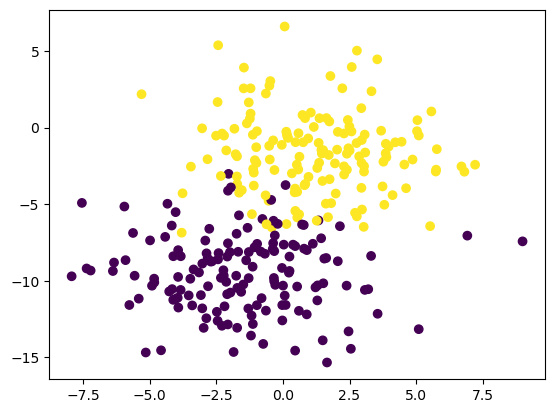

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [5]:
model = Sequential()

In [6]:
model.add(Input(shape=(2,)))
model.add(Dense(128, activation="linear"))
model.add(Dense(128, activation="linear"))
model.add(Dense(1, activation="sigmoid"))

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               384       
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 17025 (66.50 KB)
Trainable params: 17025 (66.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
adam = Adam(learning_rate=0.1)

In [9]:
model.compile(loss= 'binary_crossentropy', optimizer=adam, metrics=['accuracy'])

In [10]:
history = model.fit(X, y, epochs=50, validation_split=0.2, verbose=1)

Epoch 1/50


2026-04-04 18:40:18.583850: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type CPU is enabled.


8/8 [==============================] - 9s 431ms/step - loss: 12.2181 - accuracy: 0.6417 - val_loss: 1.7998 - val_accuracy: 0.9000
Epoch 2/50
8/8 [==============================] - 0s 47ms/step - loss: 12.0922 - accuracy: 0.8000 - val_loss: 3.7720 - val_accuracy: 0.9333
Epoch 3/50
8/8 [==============================] - 1s 75ms/step - loss: 9.0542 - accuracy: 0.8958 - val_loss: 3.2477 - val_accuracy: 0.9333
Epoch 4/50
8/8 [==============================] - 0s 51ms/step - loss: 2.4802 - accuracy: 0.9167 - val_loss: 1.9332 - val_accuracy: 0.9500
Epoch 5/50
8/8 [==============================] - 0s 36ms/step - loss: 2.7043 - accuracy: 0.9042 - val_loss: 6.7907 - val_accuracy: 0.8500
Epoch 6/50
8/8 [==============================] - 0s 43ms/step - loss: 3.9979 - accuracy: 0.8917 - val_loss: 0.1591 - val_accuracy: 0.9500
Epoch 7/50
8/8 [==============================] - 1s 73ms/step - loss: 1.9873 - accuracy: 0.8917 - val_loss: 1.6967 - val_accuracy: 0.9333
Epoch 8/50
8/8 [===================

In [11]:
from mlxtend.plotting import plot_decision_regions

9600/9600 [==============================] - 82s 9ms/step


<Axes: >

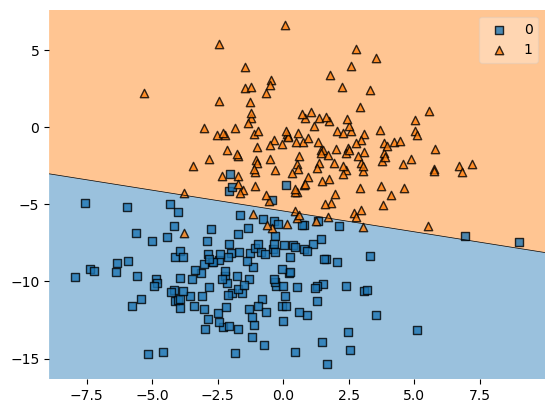

In [12]:
plot_decision_regions(X, y, clf=model)

## now with non-linear activation function

#### just before creating another model we need to clear keras backend to be safe form error and conflicts


In [36]:
import tensorflow as tf

In [37]:
tf.keras.backend.clear_session()

In [38]:
model_2 = Sequential()

In [39]:
model_2.add(Input(shape=(2, )))
model_2.add(Dense(128, activation='relu'))
model_2.add(Dense(128, activation='relu'))
model_2.add(Dense(1, activation='sigmoid'))

In [40]:
adam2 = Adam(learning_rate=0.1)

In [41]:
model_2.compile(loss='binary_crossentropy', optimizer=adam2, metrics=['accuracy'])

In [42]:
history = model.fit(X, y, epochs=300, validation_split=0.2, verbose=1)

Epoch 1/300


8/8 [==============================] - 3s 236ms/step - loss: 0.3202 - accuracy: 0.9167 - val_loss: 0.1904 - val_accuracy: 0.9333
Epoch 2/300
8/8 [==============================] - 0s 37ms/step - loss: 0.5821 - accuracy: 0.9208 - val_loss: 0.4328 - val_accuracy: 0.9333
Epoch 3/300
8/8 [==============================] - 1s 89ms/step - loss: 0.2938 - accuracy: 0.9500 - val_loss: 0.1227 - val_accuracy: 0.9667
Epoch 4/300
8/8 [==============================] - 1s 110ms/step - loss: 0.2954 - accuracy: 0.9458 - val_loss: 0.2072 - val_accuracy: 0.9500
Epoch 5/300
8/8 [==============================] - 1s 96ms/step - loss: 0.2106 - accuracy: 0.9417 - val_loss: 0.0838 - val_accuracy: 0.9667
Epoch 6/300
8/8 [==============================] - 1s 137ms/step - loss: 0.1895 - accuracy: 0.9375 - val_loss: 0.0995 - val_accuracy: 0.9500
Epoch 7/300
8/8 [==============================] - 1s 70ms/step - loss: 0.1645 - accuracy: 0.9458 - val_loss: 0.1202 - val_accuracy: 0.9333
Epoch 8/300
8/8 [============

9600/9600 [==============================] - 173s 18ms/step


<Axes: >

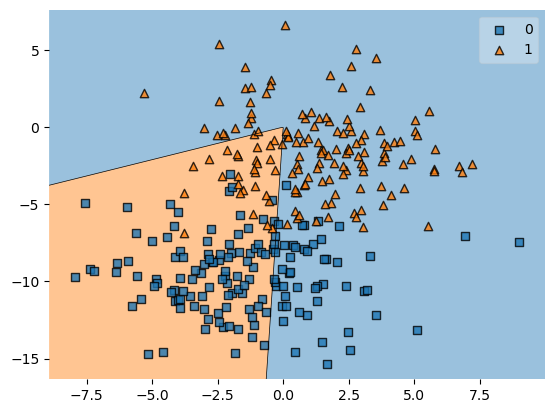

In [43]:
plot_decision_regions(X, y, clf=model_2)